#below incuded all steps evaluate and prediction mnist

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Load and Prepare the Dataset
# The dataset is conveniently provided by Keras and already split into train/test sets.
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Preprocess the data: normalize pixel values from [0, 255] to [0, 1].
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images to add a channel dimension (needed for CNNs).
# MNIST images are 28x28 grayscale, so the shape becomes (num_samples, 28, 28, 1).
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

# 2. Build the CNN Architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), # First convolutional layer
    MaxPooling2D((2, 2)),                                        # Max pooling layer
    Conv2D(64, (3, 3), activation='relu'),                       # Second convolutional layer
    MaxPooling2D((2, 2)),                                        # Max pooling layer
    Flatten(),                                                   # Flatten the 3D output to 1D
    Dense(64, activation='relu'),                                # Fully connected dense layer
    Dense(10, activation='softmax')                              # Output layer with 10 classes
])

# 3. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Use this loss for integer labels
              metrics=['accuracy'])

# 4. Train the Model (on training data)
model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_split=0.1)

# 5. Evaluate the Model (on the test dataset)
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc}')

# 6. Make Predictions
# To predict on new data, use the `model.predict()` method.
predictions = model.predict(test_images[:5])
predicted_classes = np.argmax(predictions, axis=1)

print('\nPredictions for the first 5 test images:', predicted_classes)
print('Actual labels for the first 5 test images:', test_labels[:5])


In [ ]:
############

# using tfds load

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
import PIL
import cv2

In [42]:
# from datasets import load_dataset # hugging face datset

In [43]:
# ?tfds.load

In [44]:
(train_ds, test_ds), ds_info = tfds.load(
    name='cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True, #(inp,lab) tuble structure, if False(default) willbe dictionary sturcture
    shuffle_files=True
    )

In [45]:
LABELS=['Cat', 'Dog']
IMAGE_SIZE=(152, 152)
BATCH_SIZE = 32
# [*train_ds.take(2)]

In [46]:
fig, ax = plt.subplots(4,5, figsize=(20,20))
ax = ax.flatten()
for i, (im, la) in enumerate(train_ds.skip(20).take(20)):
  ax[i].imshow(im,) #im_dict['image'])
  ax[i].set_title(LABELS[la]) #im_dict['label']])


Output hidden; open in https://colab.research.google.com to view.

In [47]:
def preprocess(im, la):
    # if not 3d array or channel is not rgb
    # then convert the data
    # if tf.rank(im) != 3:
    #    im=tf.expand_dims(im, axis=-1)
    # if tf.shape(im)[-1] !=3:
    #    im = tf.image.grayscale_to_rgb(tf.constant(im)).numpy()
    im = tf.image.resize(im, IMAGE_SIZE)
    # im = cv2.resize(im, IMAGE_SIZE)
    im = im / 255
    return im, la

# tensor dataset iterate as tensor tuple having image and label
# set batch after map to resolve shape attribute-error
train_ds = train_ds.map(preprocess,
                        num_parallel_calls=tf.data.AUTOTUNE, #parallel preprocessing
                                )
test_ds = test_ds.map(preprocess,
                      num_parallel_calls=tf.data.AUTOTUNE)


In [48]:
# [*test_ds.take(2)]

In [49]:
#data pipeline
train_ds = (
    train_ds
    .cache() # keep data in memory for next epochs
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE) # prallel data fetching for next epoch
)

test_ds = (
    test_ds
    # .cache() # no need for test ds
    # .shuffle(1000) #should not for test ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
model = tf.keras.Sequential()

model.add(
    tf.keras.layers.Conv2D(
        filters=32, kernel_size=(3, 3), stride=1, padding='same',#'valid'
        activation='relu'
    )
)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))

model.add(
    tf.keras.layers.Conv2D(
        filters=64, kernel_size=(3,3), stride=1, padding='same',
        activation='relu'
    )
)

In [50]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Conv2D(filters=32,
    kernel_size=(3,3),
    strides=1,
    padding='valid',
    activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))

model.add(tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    strides=1,
    padding='valid', # or 'sample'
    activation='relu'
    ))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))


model.add(tf.keras.layers.Conv2D(
  filters=128,
  kernel_size=(3,3),
  strides=1,
  padding='valid',
  activation='relu',
))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2)) #down sampling

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(units=512,
                                activation=tf.keras.activations.leaky_relu,
                                # regularizer=tf.keras.regularizers.l2
                                ))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Dense(units=1,
                                activation=tf.keras.activations.sigmoid))


In [51]:
# ?tf.keras.optimizers.Adam
#compile model - (basic ex: With Stochastic Gradient Descent optimizer using MSE as loss)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), #RMSProp() #SGD
    loss=tf.keras.losses.binary_crossentropy,
    metrics=['accuracy']
)

In [52]:
# ?model.fit

In [53]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    steps_per_epoch = 150, #batches of sample
    epochs=5
    )

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 451s 3s/step - accuracy: 0.6069 - loss: 4.3841 - val_accuracy: 0.5714 - val_loss: 1.4989
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 466s 3s/step - accuracy: 0.6469 - loss: 1.5411 - val_accuracy: 0.5187 - val_loss: 1.7532
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 440s 3s/step - accuracy: 0.6865 - loss: 0.7631 - val_accuracy: 0.6834 - val_loss: 0.6279
Epoch 4/5
132/150 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7030 - loss: 0.6405

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


150/150 ━━━━━━━━━━━━━━━━━━━━ 398s 3s/step - accuracy: 0.7152 - loss: 0.5995 - val_accuracy: 0.7442 - val_loss: 0.5301
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 452s 3s/step - accuracy: 0.7494 - loss: 0.5318 - val_accuracy: 0.7526 - val_loss: 0.5384


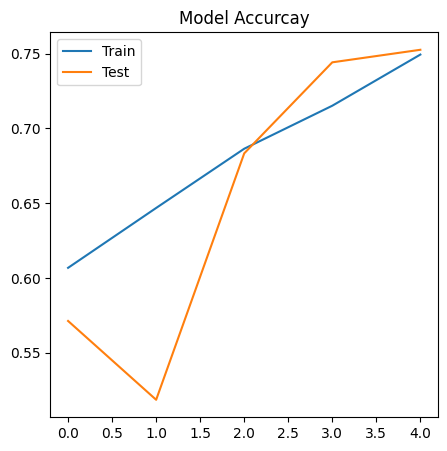

In [54]:
plt.figure(figsize=(5,5))
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.legend(['Train', 'Test'])
plt.title('Model Accurcay')
plt.show()